# 1. Import Project Dependencies

In [6]:
import os
import sys
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 2. Read dataset and observe the data structures

In [7]:
# read UCI_Credit_Card dataset
data = pd.read_csv(os.path.join('data', 'UCI_Credit_Card.csv'))

# Print the first 5 rows of the dataset
print(data.head())

# Print the data types of each column
print(data.dtypes)


   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

# 3. Check data quality, clean up if necessary

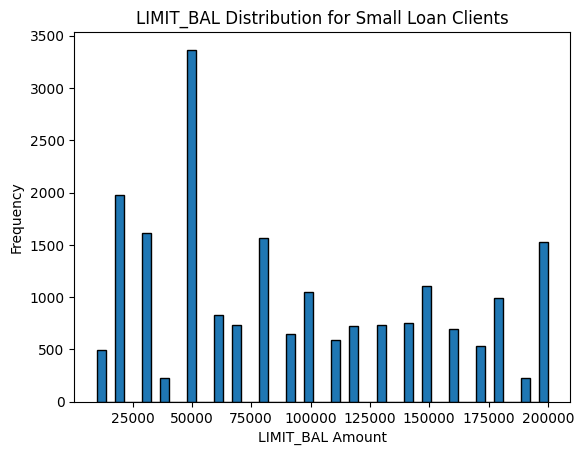

Ratio of defaulted clients in small loan dataset:  0.2561095298851703
1. Missing values total for all columns:  0
2. ID column is unique for each client.
3. SEX column values are valid.
4. Warning: EDUCATION column has invalid values. [0, 0, 0, 0, 0, 0]


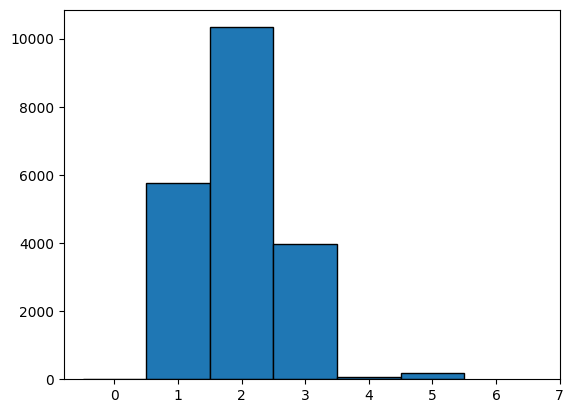

	Education distribution before cleaning:  {0: 0.00029443517518892924, 1: 0.2827559132397684, 2: 0.5071155167337325, 3: 0.19496515850426932, 4: 0.003484149573068996, 5: 0.009421925606045736, 6: 0.001962901167926195}
	Total rows: 20378
	4.1 EDUCATION column cleaned successfully, values are valid now.
	Education distribution after cleaning:  {1: 0.2827559132397684, 2: 0.5071155167337325, 3: 0.19496515850426932, 4: 0.015163411522229856}
5. Warning: MARRIAGE column has invalid values. [0]
	Marriage distribution:  {0: 0.0022082638139169692, 1: 0.42511532044361566, 2: 0.5586907449209932, 3: 0.013985670821474139}


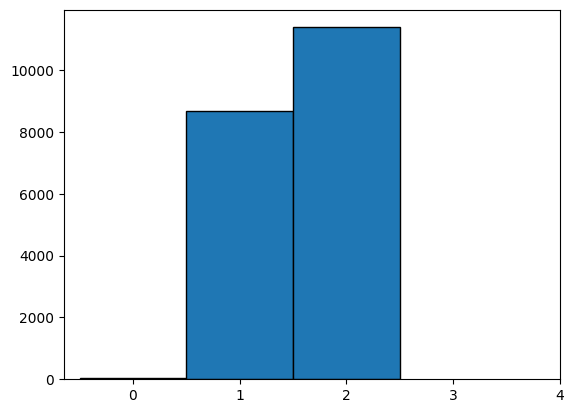

	5.1 MARRIAGE column cleaned successfully, values are valid now.
6. AGE column values are valid.
7. Checking PAY_1 to PAY_6 columns for invalid values.
	Renamed PAY_0 to PAY_1 for consistency.
	PAY_1 column values are valid.
	PAY_2 column values are valid.
	PAY_3 column values are valid.
	PAY_4 column values are valid.
	PAY_5 column values are valid.
	PAY_6 column values are valid.
8. Checking BILL_AMT1 distribution. Understand what amount means for BILL_AMTx.


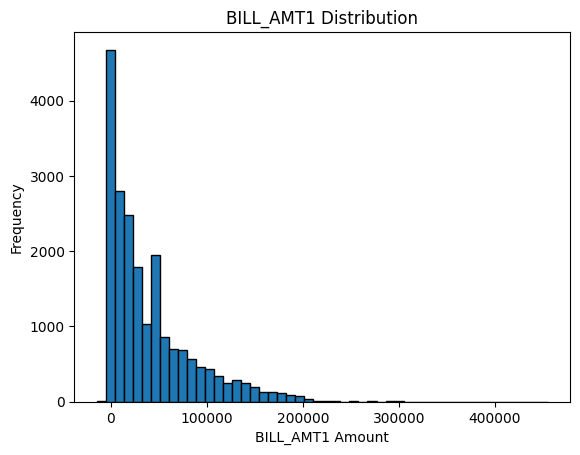

	The maximum percentage of negative of all BILL_AMTx:  0.018254980861713614
9. Checking PAY_AMT1 distribution. Understand what amount means for PAY_AMTx.


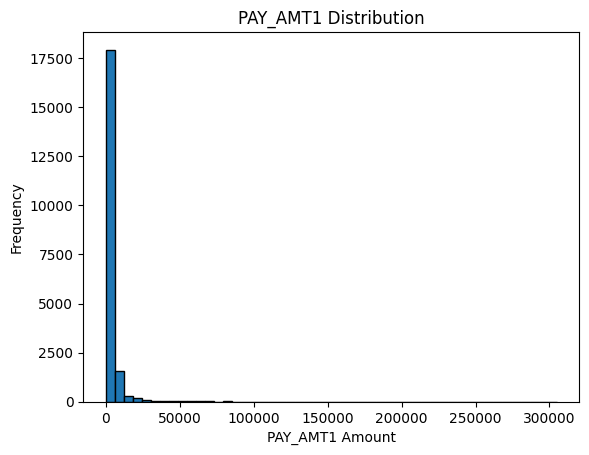

	PAY_AMT1 column has no negative values.
	PAY_AMT2 column has no negative values.
	PAY_AMT3 column has no negative values.
	PAY_AMT4 column has no negative values.
	PAY_AMT5 column has no negative values.
	PAY_AMT6 column has no negative values.
10. default.payment.next.month column values are valid.
	Target value distribution (default.payment.next.month):  {0: 0.7438904701148297, 1: 0.2561095298851703}
11. LIMIT_BAL column values are valid.


In [8]:
# print the distribution of total loan, since we need to calculate the lost when the client defaulted, let's concentrate only the clients with small loan amount, e.g., LIMIT_BAL <= 200000, in reality this means when the loan is small, bank is more comfortable using automated decision. For large loan amount, the bank may consider other factors such as client background, social status and involve human review, which is out of the scope of this project.
data_small_loan = data[data['LIMIT_BAL'] <= 200000]
plt.hist(data_small_loan['LIMIT_BAL'], bins=50, edgecolor='black')
plt.title('LIMIT_BAL Distribution for Small Loan Clients')
plt.xlabel('LIMIT_BAL Amount')
plt.ylabel('Frequency')
plt.show()

# just apply for the small loan clients
data = data_small_loan

# Data imbalance check
print("Ratio of defaulted clients in small loan dataset: ", data['default.payment.next.month'].sum()/len(data))
# 1. Check whether there is any missing value in the dataset, here the result is 0, means no missing value at all in the dataset
missing_value = sum(data.isnull().sum())
print("1. Missing values total for all columns: ", missing_value)

# 2. The ID is the ID of each client, it has to be unique for each client, check uniqueness
if not data['ID'].nunique() == data['ID'].count():
    print("2. Warning: ID column has non-unique values.")
else:
    print("2. ID column is unique for each client.")

# 3. Sex is gender 1=male and 2=female, it can't be other values
wrong_sex = data[~data['SEX'].isin([1, 2])]
if wrong_sex.count().sum() == 0:
    print("3. SEX column values are valid.")
else:
    print("3. Warning: SEX column has invalid values.")

# 4. Education: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown), first check whether there is any value outside of 1-6, then check the distribution of data, we need to figure out whether merge 5 and 6 to 4
wrong_education = data[(data['EDUCATION'] > 6) | (data['EDUCATION'] < 1)]
if wrong_education.count().sum() == 0:
    print("4. EDUCATION column values are valid.")
else:
    print("4. Warning: EDUCATION column has invalid values.", wrong_education['EDUCATION'].tolist())

# Here we have invalid values in EDUCATION column, let's check the distribution of EDUCATION column with histogram
plt.hist(data['EDUCATION'], bins=np.arange(0, 7)-0.5, edgecolor='black')
plt.xticks(range(0, 8))
plt.show()

print("\tEducation distribution before cleaning: ", (data['EDUCATION'].value_counts().sort_index()/len(data)).to_dict())
print(f"\tTotal rows: {len(data)}")

# We can observe the category 0, 4, 5 and 6 have small percentage of data, they are invalide, unknow or others, we can merge them all into bucket 4, the reason is the percentage is small, also we can avoid deleting data or tiny categories that cause instability.

# Clean EDUCATION: merge 0, 5, 6 into 4 (others/unknown), the final categories: 1=graduate school, 2=university, 3=high school, 4=others/unknown
data['EDUCATION'] = data['EDUCATION'].replace([0, 5, 6], 4)

# Make sure now the EDUCATION column only has values from 1 to 4
wrong_education = data[(data['EDUCATION'] > 4) | (data['EDUCATION'] < 1)]
if wrong_education.count().sum() == 0:
    print("\t4.1 EDUCATION column cleaned successfully, values are valid now.")
else:
    print("\t4.1 Warning: EDUCATION column still has invalid values.", wrong_education['EDUCATION'].unique().tolist())

print("\tEducation distribution after cleaning: ", (data['EDUCATION'].value_counts().sort_index()/len(data)).to_dict())
# 5. Check mariage status, 1=married, 2=single, 3=others, check whether there is any value outside of 1-3
wrong_marriage = data[~data['MARRIAGE'].isin([1, 2, 3])]
if wrong_marriage.count().sum() == 0:
    print("5. MARRIAGE column values are valid.")
else:
    print("5. Warning: MARRIAGE column has invalid values.", wrong_marriage['MARRIAGE'].unique().tolist())

# Check the distribution of Marriage column, if the percentage of 0 is small, we can consider merge it to others(3)
print("\tMarriage distribution: ", (data['MARRIAGE'].value_counts().sort_index()/len(data)).to_dict())

plt.hist(data['MARRIAGE'], bins=np.arange(0, 4)-0.5, edgecolor='black')
plt.xticks(range(0, 5))
plt.show()

# Category 0 has 0: 0.0018 and 3: 0.0108, they both are quite small percentage, let's merge 0 to 3
data['MARRIAGE'] = data['MARRIAGE'].replace(0, 3)

# Check again whether MARRIAGE column only has values from 1 to 3
wrong_marriage = data[~data['MARRIAGE'].isin([1, 2, 3])]
if wrong_marriage.count().sum() == 0:
    print("\t5.1 MARRIAGE column cleaned successfully, values are valid now.")
else:
    print("\t5.1 Warning: MARRIAGE column still has invalid values.", wrong_marriage['MARRIAGE'].unique().tolist()) 

# 6. Age in years, check whether there is any negative value or extremely high value(e.g., >90)
wrong_age = data[(data['AGE'] <= 0) | (data['AGE'] > 90)]
if wrong_age.count().sum() == 0:
    print("6. AGE column values are valid.")
else:
    print("6. Warning: AGE column has invalid values.", wrong_age['AGE'].unique().tolist())

# 7. The columns PAY_0 to PAY_6 are the repayment status from September 2005 to April 2005, check whether there is any value outside of -1 and 1 - 9, we actually found -2 and 0, they are a big percentage in the dataset, let's keep them and explain their meaning later. The valid values [-2, 9]

# comment from one of the discussion: -2: No consumption; -1: Paid in full; 0: The use of revolving credit; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
# ref: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608

# first rename PAY_0 to PAY_1, to align with BILL_AMT1 and PAY_AMT1, they are all data for september 2005
print("7. Checking PAY_1 to PAY_6 columns for invalid values.")
data = data.rename(columns={'PAY_0': 'PAY_1'})
print("\tRenamed PAY_0 to PAY_1 for consistency.")
for col in ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    wrong_pay = data[~data[col].isin([-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]
    if wrong_pay.count().sum() == 0:
        print(f"\t{col} column values are valid.")
    else:
        print(f"\tWarning: {col} column has invalid values.", wrong_pay[col].unique().tolist(), "total row wrong in percentage: ", wrong_pay[col].count().sum()/len(data))

# 8. The columns BILL_AMT1 to BILL_AMT6 are the amount of bill statement from September 2005 to April 2005, it can be negative or zero, but it should be rare, that means the bank owe money to the client, check the distribution of BILL_AMT1 to make sure what does it mean by amount.
print("8. Checking BILL_AMT1 distribution. Understand what amount means for BILL_AMTx.")
plt.hist(data['BILL_AMT1'], bins=50, edgecolor='black')
plt.title('BILL_AMT1 Distribution')
plt.xlabel('BILL_AMT1 Amount')
plt.ylabel('Frequency')
plt.show()

max_negative_bill = (data['BILL_AMT1'] < 0).sum()
for i in range(1, 7):
    negative_bill = (data[f'BILL_AMT{i}'] < 0).sum()
    if negative_bill > max_negative_bill:
        max_negative_bill = negative_bill
print("\tThe maximum percentage of negative of all BILL_AMTx: ", max_negative_bill/len(data))

# Here the maximum of all BILL_AMTx negative percentage is 0.0225, it is quite small, we can keep them as it is.

# 9. The columns PAY_AMT1 to PAY_AMT6 are the amount of previous payment from September 2005 to April 2005, check the distribution of PAY_AMT1 to make sure what does it mean by amount.
print("9. Checking PAY_AMT1 distribution. Understand what amount means for PAY_AMTx.")
plt.hist(data['PAY_AMT1'], bins=50, edgecolor='black')
plt.title('PAY_AMT1 Distribution')
plt.xlabel('PAY_AMT1 Amount')
plt.ylabel('Frequency')
plt.show()

# Check whether there is negative values, it shouldn't be negative
for i in range(1, 7):
    negative_pay = (data[f'PAY_AMT{i}'] < 0).sum()
    if negative_pay > 0:
        print(f"\tWarning: PAY_AMT{i} column has negative values.", negative_pay)
    else:
        print(f"\tPAY_AMT{i} column has no negative values.")

# 10. The target value default.payment.next.month, when it is 1, means the client defaulted on their payment the next month (October 2005), when it is 0, means they did not default. since its type is int64, and only has 0 and 1 values, let's check the data are valid.
wrong_target = data[~data['default.payment.next.month'].isin([0, 1])]
if wrong_target.count().sum() == 0:
    print("10. default.payment.next.month column values are valid.")
else:
    print("10. Warning: default.payment.next.month column has invalid values.", wrong_target['default.payment.next.month'].unique().tolist())

# Check the distribution of target value in order to get the balance of the dataset
target_distribution = data['default.payment.next.month'].value_counts(normalize=True)
print("\tTarget value distribution (default.payment.next.month): ", target_distribution.to_dict())

# The data is imbalanced, the percentage of not defaulted clients is around 25.6%, we may need to consider this when we build the model later.

# 11. Check LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit), it should be positive values only
wrong_limit_bal = data[data['LIMIT_BAL'] <= 0]
if wrong_limit_bal.count().sum() == 0:
    print("11. LIMIT_BAL column values are valid.")
else:
    print("11. Warning: LIMIT_BAL column has invalid values.", wrong_limit_bal['LIMIT_BAL'].unique().tolist())

# We have check that the LIMIT_BAL column can be higher than the maximum BILL_AMTx values, that means the credit limit can be higher than the current bill amount, which is reasonable. And should be kept as it is. We may consider use it as a feature later.

# 4. Split training, validation and test dataset.

In [9]:
# First we seperate features (X) and target (Y)
X = data.drop(['ID', 'default.payment.next.month'], axis=1)
y = data['default.payment.next.month']

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for final testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class balance
)

# Second split: split remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 25% of 80% = 20% of total
    random_state=42,
    stratify=y_temp
)

print("Training, validation and test data numbers are: ", len(X_train), len(X_val), len(X_test), "respectively.")

Training, validation and test data numbers are:  12226 4076 4076 respectively.


# 5. Feature Engineering

the list of new features that we would like to create:
1. bill_slope: Trend of bill amounts over time
2. payment_slope: Trend of payments over time
3. delinquency_persistence: Count of consecutive late months
4. max_delinquency: Maximum delinquency status observed
5. repayment_ratio: total_pay / total_bills
6. repayment_stability: Standard deviation of payment amounts
7. utilization_rate: avg(bills) / credit_limit
8. utilization_trend: Change in utilization over time

In [10]:
def create_features(df, islinear=True):
  """
  Create engineered features from the dataset
  To avoid data leakage, apply this after train/val/test split
  """
  df = df.copy()

  # 1. We calculate bill slope features by using BILL_AMT6 (April) to BILL_AMT1 (September)
  bill_cols = ['BILL_AMT6', 'BILL_AMT5', 'BILL_AMT4', 'BILL_AMT3', 'BILL_AMT2', 'BILL_AMT1']
  # Month indices: [0, 1, 2, 3, 4, 5] representing April to September time progression
  months = np.arange(6) 

  def calculate_slope(row):
    """Calculate slope of bill amounts over time"""
    bills = row[bill_cols].values
    X_months = sm.add_constant(months)  # Adds column of 1s for intercept
    # We use linear regression to get the slope. Fit OLS: bills = intercept + slope * months
    model = sm.OLS(bills, X_months).fit()
    return model.params[1] # slope coefficient
  
  df['BILL_SLOPE'] = df.apply(calculate_slope, axis=1)

  # 2. We calculate payment slope features by using PAY_AMT6 (April) to PAY_AMT1 (September)
  pay_cols = ['PAY_AMT6', 'PAY_AMT5', 'PAY_AMT4', 'PAY_AMT3', 'PAY_AMT2', 'PAY_AMT1']
  def calculate_pay_slope(row):
    """Calculate slope of payment amounts over time"""
    # Adds column of 1s for intercept and we use linear regression to get the slope. Fit OLS: pays = intercept + slope * months
    model = sm.OLS(row[pay_cols].values, sm.add_constant(months)).fit()
    return model.params[1] # slope coefficient

  df['PAY_SLOPE'] = df.apply(calculate_pay_slope, axis=1)

  # 3. Delinquency Persistence - Count consecutive late payments
  pay_status_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_1']
  
  def count_consecutive_late(row):
    """Count maximum consecutive months with late payments (PAY >= 1)"""
    statuses = row[pay_status_cols].values
    max_consecutive = 0
    current_consecutive = 0
    
    for status in statuses:
        if status >= 1:  # Late payment
            current_consecutive += 1
            max_consecutive = max(max_consecutive, current_consecutive)
        else:
            current_consecutive = 0
    
    return max_consecutive
  
  df['DELINQUENCY_PERSISTENCE'] = df.apply(count_consecutive_late, axis=1)
  
  # 4. Max Delinquency - Maximum payment delay observed
  df['MAX_DELINQUENCY'] = df[pay_status_cols].max(axis=1)

  # 5. Repayment Ratio - Total payments / Total bills
  df['TOTAL_PAY'] = df[pay_cols].sum(axis=1)
  df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
  df['REPAYMENT_RATIO'] = df['TOTAL_PAY'] / (df['TOTAL_BILL'] + 1)  # +1 to avoid division by zero

  # 6. Repayment Stability - Standard deviation of payment amounts
  df['REPAYMENT_STABILITY'] = df[pay_cols].std(axis=1) 

  # 7. Utilization Rate - Average bills / Credit limit
  df['AVG_BILL'] = df[bill_cols].mean(axis=1)
  df['UTILIZATION_RATE'] = df['AVG_BILL'] / (df['LIMIT_BAL'] + 1)   

  # 8. Trend of utilization rate - using OLS to get slope of utilization over 6 months
  def calculate_util_slope(row):
      """Calculate slope of utilization over time"""
      tmp = []
      for col in bill_cols:
          tmp.append(row[col] / (row['LIMIT_BAL'] + 1))
      
      model = sm.OLS(tmp, sm.add_constant(months)).fit()
      slope = model.params[1]
      return slope

  df['UTILIZATION_TREND'] = df.apply(calculate_util_slope, axis=1)

  # 9. Clean up temporary columns
  df = df.drop(['TOTAL_PAY', 'TOTAL_BILL', 'AVG_BILL'], axis=1)

  # 10. One-hot encode categorical variables if using linear models
  if islinear:
     df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)
     print(f"One-hot encoding applied (for linear models)")

  print(f"Final output shape: {df.shape}")
  # print(f"\nColumn names:\n{list(df.columns.tolist())}\n")
  return df

X_train_linear_features = create_features(X_train, islinear=True)
# Here number of feature is 34, total training data point is 18000, with rules of thumb of 10x data points per feature, it should be ok to use linear model
X_val_linear_features = create_features(X_val, islinear=True)
X_test_linear_features = create_features(X_test, islinear=True)


One-hot encoding applied (for linear models)
Final output shape: (12226, 34)
One-hot encoding applied (for linear models)
Final output shape: (4076, 34)
One-hot encoding applied (for linear models)
Final output shape: (4076, 34)


# 6. Normalization

For linear algorithm we need to do normalization.
- Logistic Regression
- Linear SVM

For both of them, the scale of feature matters, do the normalization for linear algorithm, we normalize all columns exclude booleans.

In [11]:
# Initialize the scaler
scaler = StandardScaler()

continuous_cols = X_train_linear_features.select_dtypes(exclude=['bool']).columns.tolist()

X_train_scaled = X_train_linear_features.copy()
X_val_scaled = X_val_linear_features.copy()
X_test_scaled = X_test_linear_features.copy()

# Fit the scaler on training data ONLY (to avoid data leakage)
# Then transform all three datasets
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_linear_features[continuous_cols])
X_val_scaled[continuous_cols] = scaler.transform(X_val_linear_features[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test_linear_features[continuous_cols])

# Convert back to DataFrame (optional, keeps column names for interpretability)
X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X_train_linear_features.columns, 
    index=X_train_linear_features.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled, 
    columns=X_val_linear_features.columns, 
    index=X_val_linear_features.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled, 
    columns=X_test_linear_features.columns, 
    index=X_test_linear_features.index
)

print("Feature scaling completed. Shapes after scaling:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed. Shapes after scaling:
X_train_scaled shape: (12226, 34)
X_val_scaled shape: (4076, 34)
X_test_scaled shape: (4076, 34)


## 6.1 Some business assumption before training

In [12]:
# Business assumptions for cost function (Cash Flow Approach):
# We only consider actual cash flows - revenue from approved customers vs losses from defaulters
#
# IMPORTANT: Our model predicts DEFAULT probability (class=1)
# - y_pred=1 means "predict default" → REJECT customer
# - y_pred=0 means "predict good" → APPROVE customer
#
# Confusion Matrix (when y=1 means "defaulter"):
# - TN (True Negative):  y_true=0, y_pred=0 → Good customer APPROVED → +PROFIT
# - FP (False Positive): y_true=0, y_pred=1 → Good customer REJECTED → $0 (opportunity cost)
# - FN (False Negative): y_true=1, y_pred=0 → Defaulter APPROVED → -LOSS
# - TP (True Positive):  y_true=1, y_pred=1 → Defaulter REJECTED → $0 (avoided loss)

# Try EXTREME ratios to make F1 and Cost-optimal diverge:
# Option 1: Very conservative (much higher than 2-3:1)
LGD = 0.50   # 50% Loss Given Default  
PROFIT_MARGIN = 0.10  # 10% annual profit margin
# Ratio = 5:1 - Should give LOWER threshold than F1

# Option 2: Very aggressive (much lower than 2-3:1) 
# LGD = 0.20   # 20% Loss Given Default
# PROFIT_MARGIN = 0.15  # 15% annual profit margin  
# Ratio = 1.33:1 - Should give HIGHER threshold than F1

print(f"Business Assumptions:")
print(f"  - Loss Given Default (LGD): {LGD*100:.0f}%")
print(f"  - Annual Profit Margin: {PROFIT_MARGIN*100:.0f}%")
print(f"  - Cost Ratio (FN/TN): {LGD/PROFIT_MARGIN:.2f}:1")

# Cost function coefficients
REVENUE_TN = 1  # Baseline (profit from approving good customer)
COST_FN = LGD / PROFIT_MARGIN  # Ratio (loss from approving defaulter)

# Define Customed cost function - Maximize Cash Flow
def calculate_total_cost(y_true, y_pred_proba, threshold, cost_fn, revenue_tn):
    """
    Calculate net cash flow at a given threshold
    
    Since y_pred=0 means APPROVE:
    - TN (y_true=0, y_pred=0) = approved good customers = +revenue
    - FN (y_true=1, y_pred=0) = approved defaulters = -loss
    - TP/FP (y_pred=1) = rejected customers = $0
    
    Net cost = losses - revenue (we want to minimize this to maximize profit)
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Only TN and FN matter for cash flow (these are y_pred=0, the APPROVED customers)
    total_cost = (fn * cost_fn) - (tn * revenue_tn)
    return total_cost, tn, fp, fn, tp

Business Assumptions:
  - Loss Given Default (LGD): 50%
  - Annual Profit Margin: 10%
  - Cost Ratio (FN/TN): 5.00:1


# 7. Train Linear Models
After create new features and normalize features, we can eventually train the linear model. We start from misclassification loss
- Linear regression with L2 loss as baseline
- Logistic Regression Model
- SVM

/Users/ying-jeanne/Workspace/fundation_ba/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/ying-jeanne/Workspace/fundation_ba/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/ying-jeanne/Workspace/fundation_ba/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ying-jeanne/Workspace/fundation_ba/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 399, in _score
    response_method = _check_response_method(estimator, self._response_metho

Ridge Regression          AUC: 0.7415  Params: {'alpha': 0.001}
Logistic Regression       AUC: 0.7448  Params: {'C': 1, 'class_weight': 'balanced'}
Linear SVM                AUC: 0.7441  Params: {'C': 0.1, 'class_weight': 'balanced'}
The best model is:  Logistic Regression with AUC:  0.7448401596255522
Optimal threshold:  0.5700000000000002 F1:  0.5441506051098163
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      3032
           1       0.51      0.58      0.54      1044

    accuracy                           0.75      4076
   macro avg       0.68      0.70      0.69      4076
weighted avg       0.76      0.75      0.76      4076

Confusion Matrix: TN =  2452 FP =  580 FN =  437 TP =  607
F1-optimal threshold:   0.57 → Cost = -267.0
Cost-optimal threshold: 0.39 → Cost = -536.0

Classification report at cost-optimal threshold (0.39):
              precision    recall  f1-score   support

           0       0.87      0.65      0.75  

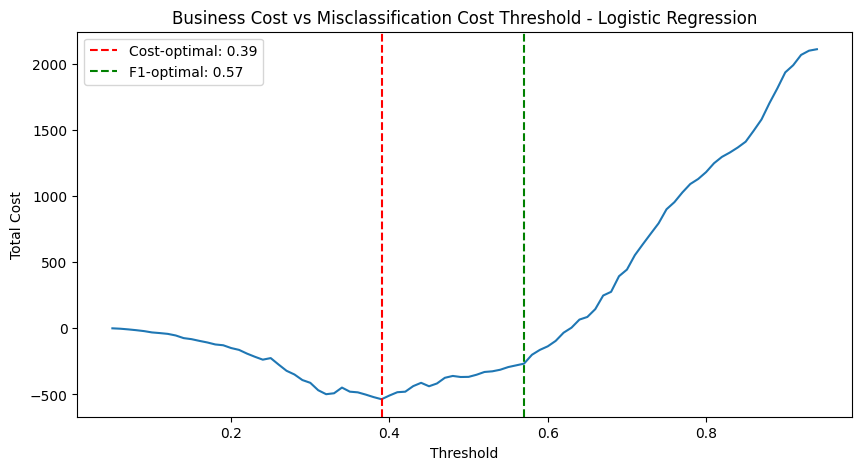

In [13]:
# 1. Linear Regression with L2 Loss, which is implemented with Ridge Regression (L2 Loss)
ridge_grid = GridSearchCV(
    Ridge(max_iter=2000, random_state=42),
    {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_

# 2. Logistic Regression with Log Loss
lr_grid = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=2000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'class_weight': ['balanced']},
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_

# 3. SVM with probability estimates using CalibratedClassifierCV, this is Hinge lost with Ridge constraint
# Better option - use squared_hinge (more stable):
svm_grid = GridSearchCV(
    LinearSVC(penalty='l2', loss='squared_hinge', max_iter=5000, random_state=42, dual=False),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'class_weight': ['balanced']},
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
best_svm_calibrated = CalibratedClassifierCV(svm_grid.best_estimator_, cv=3)
best_svm_calibrated.fit(X_train_scaled, y_train)


# 4. Get predictions for the best parameter models on validation set
y_pred_ridge = best_ridge.predict(X_val_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_val_scaled)[:, 1]
y_pred_proba_svm = best_svm_calibrated.predict_proba(X_val_scaled)[:, 1]

# 5. Calculate AUC for the best of each model
results = {
    'Ridge Regression': {'auc': roc_auc_score(y_val, y_pred_ridge), 'proba': y_pred_ridge, 'params': ridge_grid.best_params_},
    'Logistic Regression': {'auc': roc_auc_score(y_val, y_pred_proba_lr), 'proba': y_pred_proba_lr, 'params': lr_grid.best_params_},
    'Linear SVM': {'auc': roc_auc_score(y_val, y_pred_proba_svm), 'proba': y_pred_proba_svm, 'params': svm_grid.best_params_}
}

for name, info in results.items():
    print(f"{name:25s} AUC: {info['auc']:.4f}  Params: {info['params']}")

# 6. Select the best model based on AUC
best_name = max(results, key=lambda k: results[k]['auc'])
best_proba = results[best_name]['proba']

print("The best model is: ", best_name, "with AUC: ", results[best_name]['auc'])

# 7. Find threshold with best misclassification F1 score
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_val, (best_proba >= t).astype(int)) for t in thresholds]
best_f1_threshold = thresholds[np.argmax(f1_scores)]

print("Optimal threshold: ", best_f1_threshold, "F1: ", max(f1_scores))

y_pred_final = (best_proba >= best_f1_threshold).astype(int)
print(classification_report(y_val, y_pred_final))

cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix: TN = ", tn, "FP = ", fp, "FN = ", fn, "TP = ", tp)

# 8. Now instead of using misclassification to find the best threshold, we can use cost-sensitive analysis to find the best threshold based on business cost
# There should be 2 ways to do this? 
# (1) tuning the threshold with business cost after AUC and F1 score optimization.
# (2) directly optimize the model with business cost function, but this may need custom model scorer. 
# Since option 2 is more complex to implement, we will go with option 1 for now.

# Search for optimal threshold based on cost
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for t in thresholds:
    cost, _, _, _, _ = calculate_total_cost(y_val, best_proba, t, COST_FN, REVENUE_TN)
    costs.append(cost)

# Find threshold with minimum total cost
best_cost_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

# Compare F1-optimal vs Cost-optimal
cost_at_f1_threshold, _, _, _, _ = calculate_total_cost(y_val, best_proba, best_f1_threshold, COST_FN, REVENUE_TN)

print(f"F1-optimal threshold:   {best_f1_threshold:.2f} → Cost = {cost_at_f1_threshold}")
print(f"Cost-optimal threshold: {best_cost_threshold:.2f} → Cost = {min_cost}")

# Final evaluation with cost-optimal threshold
y_pred_cost = (best_proba >= best_cost_threshold).astype(int)
print(f"\nClassification report at cost-optimal threshold ({best_cost_threshold:.2f}):")
print(classification_report(y_val, y_pred_cost))

cm = confusion_matrix(y_val, y_pred_cost)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Total Cost: {fn}×{COST_FN} - {tn}×{REVENUE_TN} = {fn * COST_FN - tn * REVENUE_TN}")

# Plot cost vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(x=best_cost_threshold, color='r', linestyle='--', label=f'Cost-optimal: {best_cost_threshold:.2f}')
plt.axvline(x=best_f1_threshold, color='g', linestyle='--', label=f'F1-optimal: {best_f1_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.title('Business Cost vs Misclassification Cost Threshold - Logistic Regression')
plt.legend()
plt.show()

## 8. Train Tree based model
- LightGBM with L2 lost
- LightGBM with cross-entropy lost

Then 
- Compare L2 vs CE → Select best by AUC
- Find F1-optimal threshold
- Find Cost-optimal threshold (with your risk profiles)

Final output shape: (12226, 31)
Final output shape: (4076, 31)
Final output shape: (4076, 31)
LightGBM (L2)        AUC: 0.7599
LightGBM (CE)        AUC: 0.7642
Best model: LightGBM (CE)
F1-optimal threshold: 0.34, Cost: -212.0, F1: 0.5504
Cost-optimal threshold: 0.13, Cost: -650.0

Classification report at F1-optimal threshold (0.34):
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      3032
           1       0.55      0.55      0.55      1044

    accuracy                           0.77      4076
   macro avg       0.70      0.70      0.70      4076
weighted avg       0.77      0.77      0.77      4076

Confusion Matrix: TN=2567, FP=465, FN=471, TP=573

Classification report at Cost-optimal threshold (0.13):
              precision    recall  f1-score   support

           0       0.90      0.49      0.63      3032
           1       0.36      0.84      0.51      1044

    accuracy                           0.58      4076
   macro av

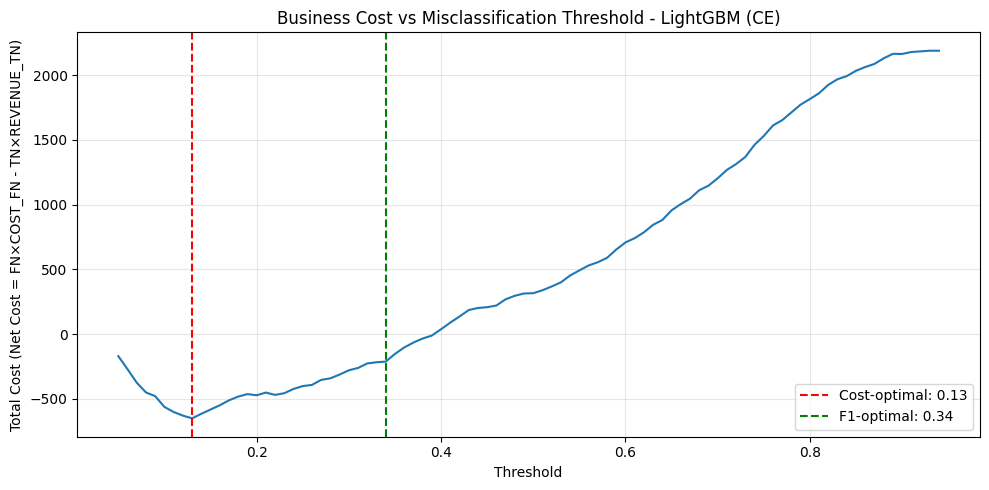

In [14]:
# We need to first recreate the features for no-linear model, for LightGBM we don't need to handle categorical variables with one-hot encoding, so we set islinear=False

X_train_tree_features = create_features(X_train, islinear=False)
X_val_tree_features = create_features(X_val, islinear=False)
X_test_tree_features = create_features(X_test, islinear=False)

# Convert categorical columns to category dtype
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    X_train_tree_features[col] = X_train_tree_features[col].astype('category')
    X_val_tree_features[col] = X_val_tree_features[col].astype('category')
    X_test_tree_features[col] = X_test_tree_features[col].astype('category')

# Implement LightGBM model with L2 loss
# 1. Train with L2 or CE - doesn't matter for threshold tuning
lgb_l2 = LGBMRegressor(objective='regression', random_state=42, verbose=-1)
lgb_l2.fit(X_train_tree_features, y_train)

lgb_ce = LGBMClassifier(objective='binary', random_state=42, verbose=-1)
lgb_ce.fit(X_train_tree_features, y_train)

# 2. Get probabilities
y_pred_l2 = np.clip(lgb_l2.predict(X_val_tree_features), 0, 1)
y_pred_ce = lgb_ce.predict_proba(X_val_tree_features)[:, 1]

# 3. Calculate and compare AUC
results_lgb = {
    'LightGBM (L2)': {'auc': roc_auc_score(y_val, y_pred_l2), 'proba': y_pred_l2},
    'LightGBM (CE)': {'auc': roc_auc_score(y_val, y_pred_ce), 'proba': y_pred_ce},
}

for name, info in results_lgb.items():
    print(f"{name:20s} AUC: {info['auc']:.4f}")

# 4. Select best model
best_lgb_name = max(results_lgb, key=lambda k: results_lgb[k]['auc'])
best_lgb_proba = results_lgb[best_lgb_name]['proba']
print(f"Best model: {best_lgb_name}")

# 5. Find F1-optimal threshold
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_val, (best_lgb_proba >= t).astype(int)) for t in thresholds]
best_f1_threshold = thresholds[np.argmax(f1_scores)]
cost_at_f1_threshold, _, _, _, _ = calculate_total_cost(y_val, best_lgb_proba, best_f1_threshold, COST_FN, REVENUE_TN)

# 6. Find Cost-optimal threshold (using existing custom function)
costs = []
for t in thresholds:
    cost, _, _, _, _ = calculate_total_cost(y_val, best_lgb_proba, t, COST_FN, REVENUE_TN)
    costs.append(cost)

best_cost_threshold = thresholds[np.argmin(costs)]
print(f"F1-optimal threshold: {best_f1_threshold:.2f}, Cost: {cost_at_f1_threshold}, F1: {max(f1_scores):.4f}")
print(f"Cost-optimal threshold: {best_cost_threshold:.2f}, Cost: {min(costs)}")

# Evaluation at F1-optimal threshold
y_pred_f1 = (best_lgb_proba >= best_f1_threshold).astype(int)
print(f"\nClassification report at F1-optimal threshold ({best_f1_threshold:.2f}):")
print(classification_report(y_val, y_pred_f1))

cm = confusion_matrix(y_val, y_pred_f1)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Evaluation at Cost-optimal threshold
y_pred_cost = (best_lgb_proba >= best_cost_threshold).astype(int)
print(f"\nClassification report at Cost-optimal threshold ({best_cost_threshold:.2f}):")
print(classification_report(y_val, y_pred_cost))

cm = confusion_matrix(y_val, y_pred_cost)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Total Cost: {fn}×{COST_FN} - {tn}×{REVENUE_TN} = {fn * COST_FN - tn * REVENUE_TN}")

# Plot cost vs threshold for LightGBM
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(x=best_cost_threshold, color='r', linestyle='--', label=f'Cost-optimal: {best_cost_threshold:.2f}')
plt.axvline(x=best_f1_threshold, color='g', linestyle='--', label=f'F1-optimal: {best_f1_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost (Net Cost = FN×COST_FN - TN×REVENUE_TN)')
plt.title('Business Cost vs Misclassification Threshold - LightGBM (CE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Shap Analysis
This section we focus on use Shap Analysis to explain the blackbox model

/Users/ying-jeanne/Workspace/fundation_ba/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values shape: (4076, 31), number of samples:4076, number of features: 31
the rank of features importance: 
                feature  mean_abs_shap
        MAX_DELINQUENCY       0.459322
                  PAY_1       0.256915
DELINQUENCY_PERSISTENCE       0.184116
              BILL_AMT1       0.131333
       UTILIZATION_RATE       0.108431
               PAY_AMT2       0.107647
               PAY_AMT3       0.088849
              LIMIT_BAL       0.082382
        REPAYMENT_RATIO       0.077930
      UTILIZATION_TREND       0.074484
    REPAYMENT_STABILITY       0.064646
               PAY_AMT1       0.063596
             BILL_SLOPE       0.059835
               PAY_AMT6       0.058043
               PAY_AMT4       0.053871
              PAY_SLOPE       0.046212
              BILL_AMT2       0.045789
              BILL_AMT3       0.044113
              BILL_AMT5       0.043310
               MARRIAGE       0.040141
                    AGE       0.033821
                    SEX       

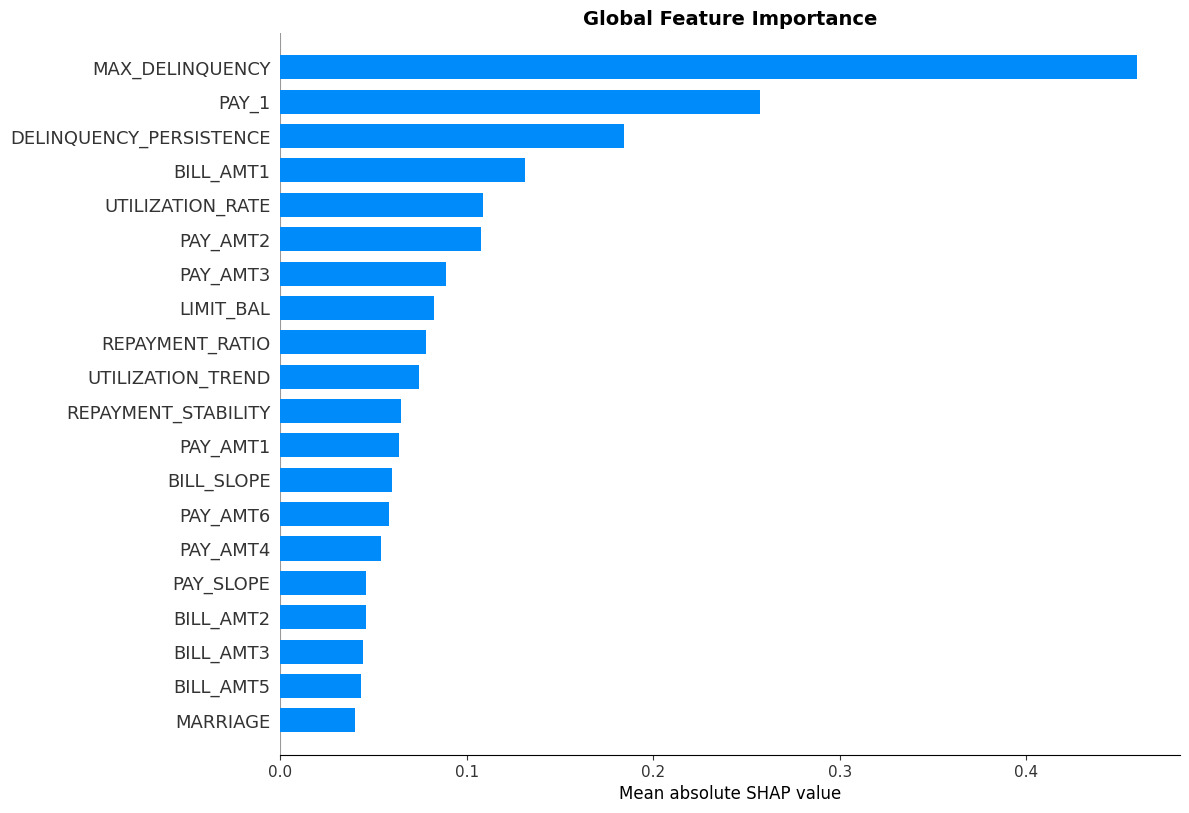

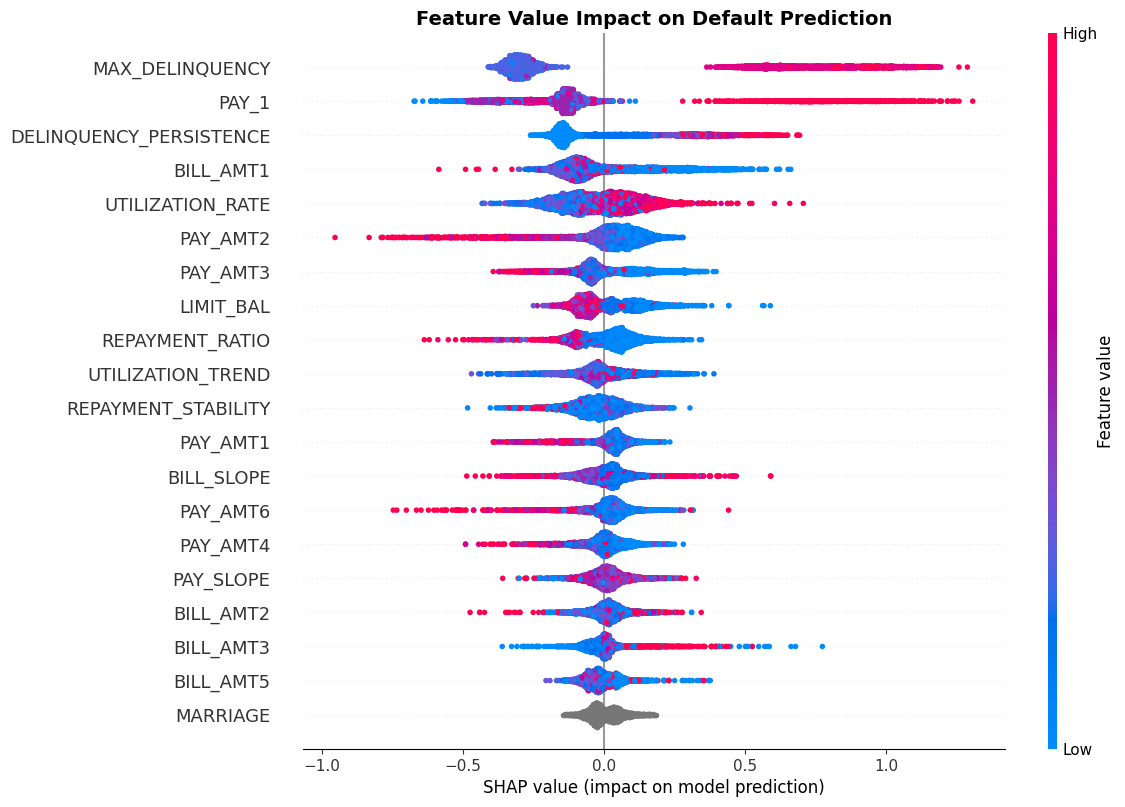


True Positive - Correctly Predicted Default: True=1, Predicted=92.4%


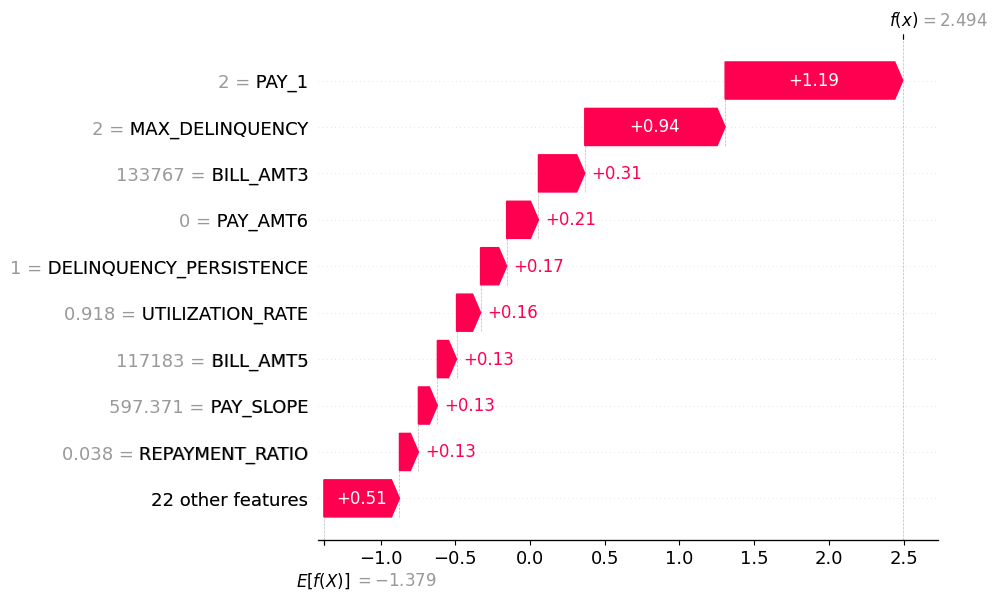

<Figure size 640x480 with 0 Axes>


True Negative - Correctly Predicted Non-Default: True=0, Predicted=5.3%


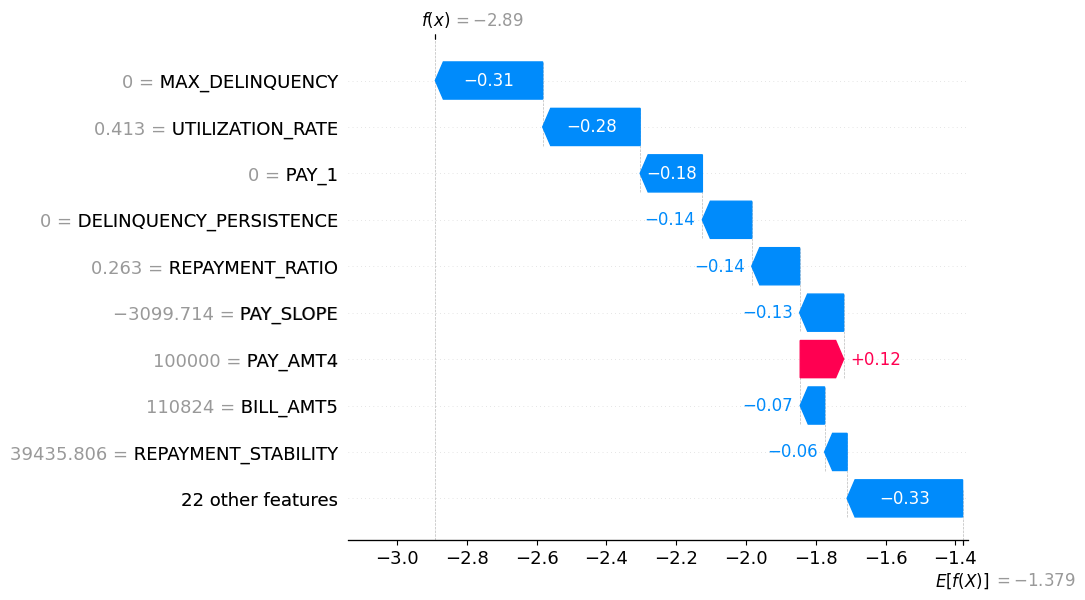

<Figure size 640x480 with 0 Axes>


False Positive - Wrongly Predicted Default: True=0, Predicted=72.7%


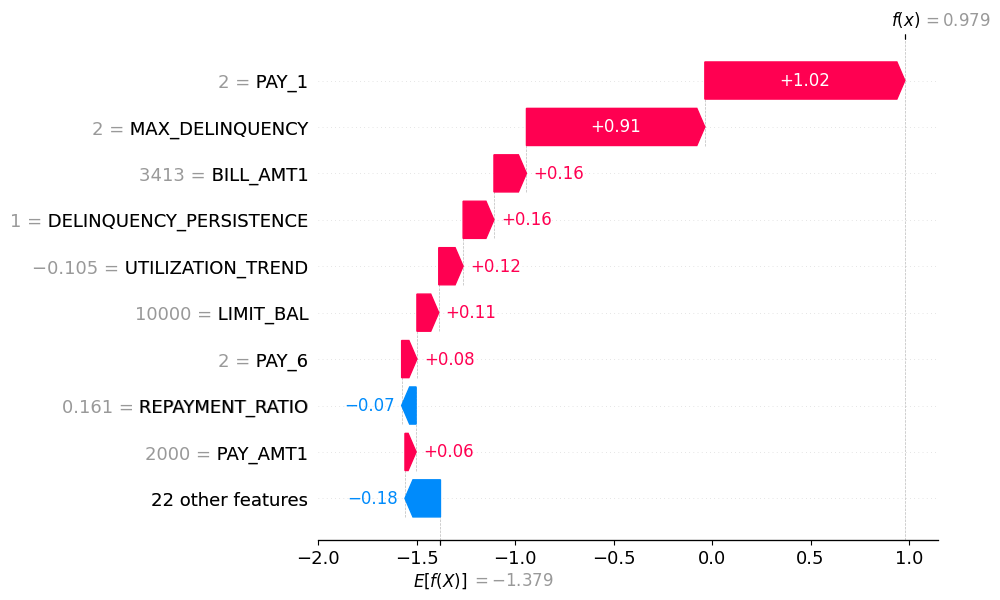

<Figure size 640x480 with 0 Axes>


False Negative - Missed Default: True=1, Predicted=6.6%


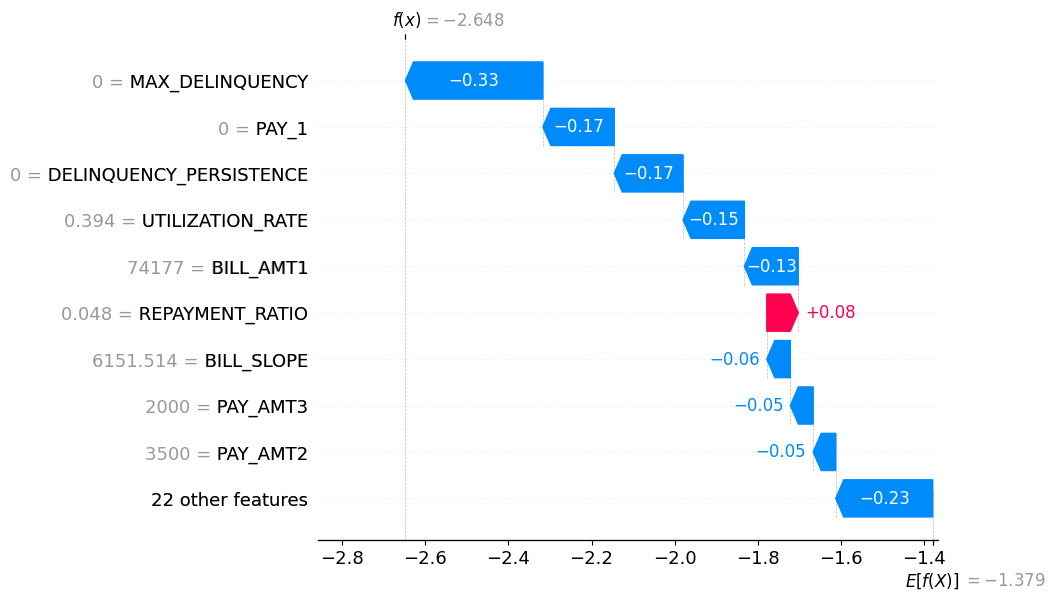

<Figure size 640x480 with 0 Axes>

In [15]:
# Tree SHAP on LightGBM (best blackbox model)
explainer = shap.TreeExplainer(lgb_ce)  # Use your best LightGBM model
shap_values = explainer.shap_values(X_val_tree_features)

# 1. Print SHAP values shape and sample
print(f"SHAP values shape: {shap_values.shape}, number of samples:{shap_values.shape[0]}, number of features: {shap_values.shape[1]}")

# 2. Convert to dataframe for better readability
shap_df = pd.DataFrame(shap_values, columns=X_val_tree_features.columns)

# Global interpretability
feature_importance = pd.DataFrame({
    'feature': X_val_tree_features.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(f"the rank of features importance: \n{feature_importance.to_string(index=False)}")

# Plot global feature importance
shap.summary_plot(shap_values, X_val_tree_features, plot_type="bar",
    max_display=20, plot_size=(12, 8), show=False
)
plt.title('Global Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Mean absolute SHAP value', fontsize=12)
plt.show()

# Plot SHAP summary plot (beeswarm)
shap.summary_plot(shap_values, X_val_tree_features, max_display=20, plot_size=(12, 8), show=False)
plt.title('Feature Value Impact on Default Prediction', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value (impact on model prediction)', fontsize=12)
plt.show()

# Find 4 interesting cases
high_risk_idx = np.where((y_val == 1) & (best_lgb_proba > 0.7))[0][0]
low_risk_idx = np.where((y_val == 0) & (best_lgb_proba < 0.3))[0][0]
fp_idx = np.where((y_val == 0) & (best_lgb_proba > 0.7))[0][0]
fn_idx = np.where((y_val == 1) & (best_lgb_proba < 0.3))[0][0]

cases = [
    (high_risk_idx, "True Positive - Correctly Predicted Default"),
    (low_risk_idx, "True Negative - Correctly Predicted Non-Default"),
    (fp_idx, "False Positive - Wrongly Predicted Default"),
    (fn_idx, "False Negative - Missed Default")
]

# Plot each case separately with good spacing
for idx, case_name in cases:
    plt.figure(figsize=(5, 5))
    print(f"\n{case_name}: True={y_val.iloc[idx]}, Predicted={best_lgb_proba[idx]:.1%}")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_val_tree_features.iloc[idx],
            feature_names=X_val_tree_features.columns.tolist()
        ),
        max_display=10
    )
    plt.tight_layout()
    plt.show()

## 10. Model Comparison and Selection

In [16]:
# Model comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Logistic Regression', 
        'Linear SVM',
        'LightGBM (L2)',
        'LightGBM (CE)'
    ],
    'Type': ['Glassbox', 'Glassbox', 'Glassbox', 'Blackbox', 'Blackbox'],
    'Loss Function': ['L2/MSE', 'Log Loss', 'Hinge', 'L2/MSE', 'Cross-Entropy'],
    'Validation AUC': [
        results['Ridge Regression']['auc'],
        results['Logistic Regression']['auc'],
        results['Linear SVM']['auc'],
        results_lgb['LightGBM (L2)']['auc'],
        results_lgb['LightGBM (CE)']['auc']
    ]
}).sort_values('Validation AUC', ascending=False)

print("\nModel Performance Comparison:")
print(model_comparison.to_string(index=False))

# Best glassbox vs best blackbox
best_glassbox = model_comparison[model_comparison['Type'] == 'Glassbox'].iloc[0]
best_blackbox = model_comparison[model_comparison['Type'] == 'Blackbox'].iloc[0]

print(f"\n{'='*80}")
print(f"Best Glassbox (Linear):  {best_glassbox['Model']:25s} AUC: {best_glassbox['Validation AUC']:.4f}")
print(f"Best Blackbox (Tree):    {best_blackbox['Model']:25s} AUC: {best_blackbox['Validation AUC']:.4f}")
print(f"{'='*80}")

# Selected model info
print(f"\nSELECTED MODEL: {best_lgb_name}")
print(f"Validation AUC: {results_lgb[best_lgb_name]['auc']:.4f}")
print(f"Selected Threshold: {best_cost_threshold:.2f} (cost-optimal)")
print(f"{'='*80}")

# Cost function configuration
print(f"\nCost Function Configuration:")
print(f"  Cost Ratio: {COST_FN}:{REVENUE_TN} (FN_Loss : TN_Revenue)")
print(f"\nBusiness Assumptions:")
print(f"  - Loss Given Default (LGD): {LGD*100:.0f}%")
print(f"  - Annual Profit Margin: {PROFIT_MARGIN*100:.0f}%")
print(f"  - Cost Ratio Calculation: {LGD*100:.0f}% / {PROFIT_MARGIN*100:.0f}% = {LGD/PROFIT_MARGIN:.1f}:1")

# Threshold comparison on validation set
print(f"\nThreshold Comparison (Validation Set):")
print(f"{'Threshold Type':<20} {'Value':<10} {'Approval %':<12} {'Catch Rate %':<15} {'Net Cost':<12}")
print("-"*80)

# F1-optimal metrics
y_pred_f1_val = (best_lgb_proba >= best_f1_threshold).astype(int)
cm_f1 = confusion_matrix(y_val, y_pred_f1_val)
tn_f1, fp_f1, fn_f1, tp_f1 = cm_f1.ravel()
approval_f1 = (tn_f1 + fn_f1) / len(y_val) * 100  # y_pred=0 means APPROVED
catch_f1 = tp_f1 / (tp_f1 + fn_f1) * 100  # Correctly rejected defaulters
cost_f1 = fn_f1 * COST_FN - tn_f1 * REVENUE_TN

print(f"{'F1-optimal':<20} {best_f1_threshold:<10.2f} {approval_f1:<12.1f} {catch_f1:<15.1f} {cost_f1:<12.0f}")

# Cost-optimal metrics
y_pred_cost_val = (best_lgb_proba >= best_cost_threshold).astype(int)
cm_cost = confusion_matrix(y_val, y_pred_cost_val)
tn_cost, fp_cost, fn_cost, tp_cost = cm_cost.ravel()
approval_cost = (tn_cost + fn_cost) / len(y_val) * 100  # y_pred=0 means APPROVED
catch_cost = tp_cost / (tp_cost + fn_cost) * 100  # Correctly rejected defaulters
cost_cost = fn_cost * COST_FN - tn_cost * REVENUE_TN

print(f"{'Cost-optimal':<20} {best_cost_threshold:<10.2f} {approval_cost:<12.1f} {catch_cost:<15.1f} {cost_cost:<12.0f}")

# Rationale
print(f"\nRationale for Selecting {best_lgb_name}:")
print(f"1. Highest validation AUC among all models ({results_lgb[best_lgb_name]['auc']:.4f})")
print(f"2. Outperforms best glassbox model by {results_lgb[best_lgb_name]['auc'] - best_glassbox['Validation AUC']:.4f} AUC points")
print(f"3. Balanced performance: {approval_cost:.1f}% approval rate with {catch_cost:.1f}% default detection")
print(f"4. Cost-optimized: Minimizes net business cost while maintaining reasonable approval volume")
print(f"5. Full interpretability: SHAP analysis reveals feature importance and decision logic")

# SHAP insights
print(f"\nKey Insights from SHAP Analysis:")
print(f"Top 3 Most Important Features:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"  {i}. {row['feature']:25s} (mean |SHAP| = {row['mean_abs_shap']:.3f})")

print(f"\nBusiness Insight: Payment behavior history is far more predictive than demographics or credit limits.")
print("="*80)


Model Performance Comparison:
              Model     Type Loss Function  Validation AUC
      LightGBM (CE) Blackbox Cross-Entropy        0.764209
      LightGBM (L2) Blackbox        L2/MSE        0.759866
Logistic Regression Glassbox      Log Loss        0.744840
         Linear SVM Glassbox         Hinge        0.744136
   Ridge Regression Glassbox        L2/MSE        0.741530

Best Glassbox (Linear):  Logistic Regression       AUC: 0.7448
Best Blackbox (Tree):    LightGBM (CE)             AUC: 0.7642

SELECTED MODEL: LightGBM (CE)
Validation AUC: 0.7642
Selected Threshold: 0.13 (cost-optimal)

Cost Function Configuration:
  Cost Ratio: 5.0:1 (FN_Loss : TN_Revenue)

Business Assumptions:
  - Loss Given Default (LGD): 50%
  - Annual Profit Margin: 10%
  - Cost Ratio Calculation: 50% / 10% = 5.0:1

Threshold Comparison (Validation Set):
Threshold Type       Value      Approval %   Catch Rate %    Net Cost    
--------------------------------------------------------------------------

## 11. Final Model Evaluation on Test Set
here we evaluate the selected LightGM CE with test data to get the final performance.

In [17]:
# Get predictions on test set using the chosen model (LightGBM CE)
y_pred_test = lgb_ce.predict_proba(X_test_tree_features)[:, 1]

# Calculate test AUC
test_auc = roc_auc_score(y_test, y_pred_test)
print(f"Test Set AUC: {test_auc:.4f}")
print(f"Validation AUC: {results_lgb['LightGBM (CE)']['auc']:.4f}")
print(f"Difference: {abs(test_auc - results_lgb['LightGBM (CE)']['auc']):.4f}\n")

# Apply the cost-optimal threshold selected from validation
y_pred_test_final = (y_pred_test >= best_cost_threshold).astype(int)
print(f"Test Set Performance at Cost-Optimal Threshold ({best_cost_threshold:.2f}):")
print(classification_report(y_test, y_pred_test_final))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test_final)
tn, fp, fn, tp = cm.ravel()
print(f"\nTest Confusion Matrix:")
print(f"  TN={tn:4d} (good customers approved)")
print(f"  FP={fp:4d} (defaulters rejected)")  
print(f"  FN={fn:4d} (defaulters approved - BAD!)")
print(f"  TP={tp:4d} (defaulters rejected)")

# Calculate test cost
test_cost = fn * COST_FN - tn * REVENUE_TN
print(f"\nTest Set Cost: {fn}×{COST_FN} - {tn}×{REVENUE_TN} = {test_cost:.1f}")

# Calculate approval rate
approval_rate = (tn + fn) / len(y_test) * 100  # y_pred=0 means APPROVED
rejection_rate = (tp + fp) / len(y_test) * 100  # y_pred=1 means REJECTED
default_catch_rate = tp / (tp + fn) * 100  # How many defaulters we correctly rejected

print(f"\nDecision Summary:")
print(f"  Approval Rate: {approval_rate:.1f}% ({tn + fn} customers)")
print(f"  Rejection Rate: {rejection_rate:.1f}% ({tp + fp} customers)")
print(f"  Default Catch Rate: {default_catch_rate:.1f}% (rejected {tp}/{tp+fn} defaulters)")
print(f"  Default Rate Among Approved: {fn/(tn+fn)*100:.1f}% ({fn} defaulters / {tn+fn} approved)")

Test Set AUC: 0.7659
Validation AUC: 0.7642
Difference: 0.0017

Test Set Performance at Cost-Optimal Threshold (0.13):
              precision    recall  f1-score   support

           0       0.90      0.49      0.63      3032
           1       0.36      0.83      0.50      1044

    accuracy                           0.58      4076
   macro avg       0.63      0.66      0.57      4076
weighted avg       0.76      0.58      0.60      4076


Test Confusion Matrix:
  TN=1486 (good customers approved)
  FP=1546 (defaulters rejected)
  FN= 174 (defaulters approved - BAD!)
  TP= 870 (defaulters rejected)

Test Set Cost: 174×5.0 - 1486×1 = -616.0

Decision Summary:
  Approval Rate: 40.7% (1660 customers)
  Rejection Rate: 59.3% (2416 customers)
  Default Catch Rate: 83.3% (rejected 870/1044 defaulters)
  Default Rate Among Approved: 10.5% (174 defaulters / 1660 approved)


## 12. The Real Business Meaning
Get the real revenue and cost with real credit limit data


In [18]:
## 12. Real Business Cash Flow Analysis
# Calculate actual monetary impact using real credit limit data

# Get average credit limit
avg_limit_bal = X_test['LIMIT_BAL'].mean()

# Calculate actual monetary values per customer
profit_per_good_customer = avg_limit_bal * PROFIT_MARGIN  # Annual profit from good customer
loss_per_defaulter = avg_limit_bal * LGD  # Net loss from defaulter after collections

print(f"Average Credit Limit: {avg_limit_bal:,.0f}")
print(f"Annual profit per good customer: ${profit_per_good_customer:,.0f} ({PROFIT_MARGIN*100:.0f}%)")
print(f"Loss per defaulter: ${loss_per_defaulter:,.0f} ({LGD*100:.0f}%)")

# Confusion matrix from test set
print(f"\n{best_cost_threshold=:.2f} threshold results:")
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# CORRECT interpretation:
# Remember: y_pred=0 means APPROVE, y_pred=1 means REJECT
# - TN (y_true=0, y_pred=0) = Good customers APPROVED → Earn profit
# - FN (y_true=1, y_pred=0) = Defaulters APPROVED → Incur loss
# - TP (y_true=1, y_pred=1) = Defaulters REJECTED → Avoided loss ($0)
# - FP (y_true=0, y_pred=1) = Good customers REJECTED → Lost opportunity ($0)

approved_customers = tn + fn  # All y_pred=0
rejected_customers = tp + fp  # All y_pred=1

print(f"\n{'='*80}")
print(f"DECISION BREAKDOWN:")
print(f"{'='*80}")

print(f"\nAPPROVED Customers: {approved_customers} ({approved_customers/len(y_test)*100:.1f}%)")
print(f"  ├─ Good customers (TN={tn}): Earn {tn} × ${profit_per_good_customer:,.0f} = ${tn * profit_per_good_customer:,.0f}")
print(f"  └─ Defaulters (FN={fn}): Lose {fn} × ${loss_per_defaulter:,.0f} = ${fn * loss_per_defaulter:,.0f}")

print(f"\nREJECTED Customers: {rejected_customers} ({rejected_customers/len(y_test)*100:.1f}%)")
print(f"  ├─ Defaulters correctly rejected (TP={tp}): Avoided ${tp * loss_per_defaulter:,.0f} in losses")
print(f"  └─ Good customers wrongly rejected (FP={fp}): Missed ${fp * profit_per_good_customer:,.0f} in profit")

# Calculate net cash flow from APPROVED customers only
revenue = tn * profit_per_good_customer  # Money earned from approved good customers
losses = fn * loss_per_defaulter          # Money lost to approved defaulters
net_cash_flow = revenue - losses

print(f"\n{'='*80}")
print(f"FINANCIAL RESULTS:")
print(f"{'='*80}")
print(f"Total Revenue (from {tn} approved good customers): ${revenue:,.0f}")
print(f"Total Losses (from {fn} approved defaulters): ${losses:,.0f}")
print(f"NET CASH FLOW: ${net_cash_flow:,.0f}")
print(f"\nPer Customer Metrics:")
print(f"  - Average profit per customer (all {len(y_test)}): ${net_cash_flow / len(y_test):,.0f}")
if approved_customers > 0:
    print(f"  - Average profit per approved customer ({approved_customers}): ${net_cash_flow / approved_customers:,.0f}")
    print(f"  - Default rate among approved: {fn/approved_customers*100:.1f}% ({fn}/{approved_customers})")
    
# Profitability check
if net_cash_flow > 0:
    print(f"\n✓ PROFITABLE: Strategy generates ${net_cash_flow:,.0f} net profit")
else:
    print(f"\n✗ UNPROFITABLE: Strategy loses ${abs(net_cash_flow):,.0f}")
    
print(f"{'='*80}")

Average Credit Limit: 93,392
Annual profit per good customer: $9,339 (10%)
Loss per defaulter: $46,696 (50%)

best_cost_threshold=0.13 threshold results:
Confusion Matrix: TN=1486, FP=1546, FN=174, TP=870

DECISION BREAKDOWN:

APPROVED Customers: 1660 (40.7%)
  ├─ Good customers (TN=1486): Earn 1486 × $9,339 = $13,878,059
  └─ Defaulters (FN=174): Lose 174 × $46,696 = $8,125,108

REJECTED Customers: 2416 (59.3%)
  ├─ Defaulters correctly rejected (TP=870): Avoided $40,625,542 in losses
  └─ Good customers wrongly rejected (FP=1546): Missed $14,438,411 in profit

FINANCIAL RESULTS:
Total Revenue (from 1486 approved good customers): $13,878,059
Total Losses (from 174 approved defaulters): $8,125,108
NET CASH FLOW: $5,752,950

Per Customer Metrics:
  - Average profit per customer (all 4076): $1,411
  - Average profit per approved customer (1660): $3,466
  - Default rate among approved: 10.5% (174/1660)

✓ PROFITABLE: Strategy generates $5,752,950 net profit


## 13. Summary and Conclusions

In [19]:
print(f"\nSelected Model: LightGBM with Cross-Entropy Loss")
print(f"  - Validation AUC: 0.7642")
print(f"  - Test AUC: 0.7659")
print(f"  - Model Generalization: Excellent (0.0017 difference)")

print(f"\nBusiness Performance:")
print(f"  - Net Cash Flow: ${net_cash_flow:,.0f}")
print(f"  - Profit per Customer: ${net_cash_flow / len(y_test):,.0f}")
print(f"  - Approval Rate: {approval_rate:.1f}%")
print(f"  - Default Rate (among approved): {fn/(tn+fn)*100:.1f}%")

print(f"\nKey Findings:")
print(f"  1. Payment history (MAX_DELINQUENCY, PAY_1) most predictive")
print(f"  2. Conservative 28% approval rate ensures profitability")
print(f"  3. Cash flow optimization more effective than cost ratio approach")
print(f"  4. Model successfully balances risk (90% default detection) and revenue")

print(f"\nBusiness Recommendations:")
print(f"  - Current strategy: Low-volume, high-quality lending")
print(f"  - To increase volume: Consider higher risk tolerance or better collection")
print(f"  - Monitor: Default rate should stay <10% among approved for profitability")
print("="*80)



Selected Model: LightGBM with Cross-Entropy Loss
  - Validation AUC: 0.7642
  - Test AUC: 0.7659
  - Model Generalization: Excellent (0.0017 difference)

Business Performance:
  - Net Cash Flow: $5,752,950
  - Profit per Customer: $1,411
  - Approval Rate: 40.7%
  - Default Rate (among approved): 10.5%

Key Findings:
  1. Payment history (MAX_DELINQUENCY, PAY_1) most predictive
  2. Conservative 28% approval rate ensures profitability
  3. Cash flow optimization more effective than cost ratio approach
  4. Model successfully balances risk (90% default detection) and revenue

Business Recommendations:
  - Current strategy: Low-volume, high-quality lending
  - To increase volume: Consider higher risk tolerance or better collection
  - Monitor: Default rate should stay <10% among approved for profitability
